# HBB: whole vs. sum of parts (AlphaGenome)

## Imports

In [1]:
import duckdb
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.isotonic import IsotonicRegression

from alphagenome.data import gene_annotation
from alphagenome.data import genome
from alphagenome.data import transcript as transcript_utils

mpl.rcParams["figure.dpi"] = 120
mpl.rcParams["axes.spines.top"] = False
mpl.rcParams["axes.spines.right"] = False
sns.set_context("notebook")

TRACK_NAME = "EFO:0002067 total RNA-seq"
TRACK_STRAND = "."
TRACK_STRAND_COMBINED = "-"
HBB_GENE_ID = "ENSG00000244734"
CHROMOSOME = "chr11"


def _annotate_corr(ax, x, y):
    mask = np.isfinite(x) & np.isfinite(y)
    r, p = stats.pearsonr(x[mask], y[mask])
    ax.text(
        0.97, 0.97, f"R = {r:.2f}\np = {p:.1e}\nn = {mask.sum()}",
        transform=ax.transAxes, ha="right", va="top", fontsize=8,
        bbox=dict(boxstyle="round", facecolor="white", edgecolor="none", alpha=0.8),
    )

## Data

In [2]:
SCALE = "full"
ROOT = ".."
UNIQUE_VARIANT_SCORES = f"{ROOT}/results/03-analysis/hbb_k562/unique_variant_scores.{SCALE}.parquet"
UNIQUE_VARIANT_MAF = f"{ROOT}/results/03-analysis/hbb_k562/unique_variant_gnomad_maf.{SCALE}.parquet"
WHOLE_VS_SUM_PARTS = f"{ROOT}/results/03-analysis/hbb_k562/whole_vs_sum_parts.{SCALE}.parquet"
GTF_PARQUET = f"{ROOT}/data/raw/GENCODE/release_46/gencode.v46.annotation.gtf.parquet"

WINDOW = {"dev": (5221202, 5237586), "full": (4705106, 5753682)}[SCALE]
INTERVAL = genome.Interval(CHROMOSOME, *WINDOW)

con = duckdb.connect()

singles = con.execute(
    "SELECT * FROM read_parquet(?) WHERE track_name = ? AND track_strand = ?",
    [UNIQUE_VARIANT_SCORES, TRACK_NAME, TRACK_STRAND],
).df()
score_by_variant = singles.set_index("variant")["score"]

maf = con.execute("SELECT * FROM read_parquet(?)", [UNIQUE_VARIANT_MAF]).df()
maf_by_variant = maf.set_index("variant")["gnomad_maf"]

combined = con.execute(
    "SELECT * FROM read_parquet(?) WHERE track_name = ? AND track_strand = ?",
    [WHOLE_VS_SUM_PARTS, TRACK_NAME, TRACK_STRAND_COMBINED],
).df()

len(singles), len(maf), len(combined)

(47194, 47194, 1842)

## HBB TSS

In [3]:
gtf = pd.read_parquet(GTF_PARQUET)
gtf_coding = gene_annotation.filter_protein_coding(gtf)
gtf_coding = gene_annotation.filter_to_longest_transcript(gtf_coding)

transcript_extractor = transcript_utils.TranscriptExtractor(gtf_coding)
transcripts = transcript_extractor.extract(INTERVAL)
hbb_transcript = next(
    t for t in transcripts if t.gene_id is not None and t.gene_id.split(".")[0] == HBB_GENE_ID
)
tss = (
    hbb_transcript.transcript_interval.end
    if hbb_transcript.strand == "-"
    else hbb_transcript.transcript_interval.start
)
tss

/users/diasfrazer/manglada/projects/wigttsoip/src/alphagenome/src/alphagenome/data/transcript.py:661: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for chromosome, dfc in df.groupby('Chromosome')


5229395

## Per-sample variant summaries

In [4]:
def _variant_arrays(variant_id):
    if not variant_id:
        return np.array([], dtype=object), np.array([]), np.array([])
    variants, positions, scores = [], [], []
    for v in variant_id.split(";"):
        chrom, pos, ref_alt = v.split(":")
        pos_1based = int(pos) + 1
        variant = f"{chrom}:{pos_1based}:{ref_alt}"
        score = score_by_variant.get(variant, np.nan)
        if not np.isfinite(score):
            continue
        variants.append(variant)
        positions.append(pos_1based)
        scores.append(score)
    return np.array(variants, dtype=object), np.array(positions, dtype=float), np.array(scores)


def _nn_dist(positions):
    if len(positions) < 2:
        return np.nan
    sp = np.sort(positions)
    gaps = np.diff(sp)
    left = np.concatenate(([np.inf], gaps))
    right = np.concatenate((gaps, [np.inf]))
    return np.median(np.minimum(left, right))


rows = []
for variant_id in combined["variant_id"]:
    variants, positions, scores = _variant_arrays(variant_id)
    nn_dist = _nn_dist(positions)
    rows.append({
        "variants": variants, "positions": positions, "scores": scores,
        "n_variants_used": len(scores),
        "median_log10_nn_dist": np.log10(nn_dist) if nn_dist > 0 else np.nan,
    })
combined = pd.concat([combined, pd.DataFrame(rows, index=combined.index)], axis=1)
combined["n_variants_used"].describe()

count    1842.000000
mean     2828.314332
std       374.780646
min      1556.000000
25%      2570.000000
50%      2844.500000
75%      3090.750000
max      3837.000000
Name: n_variants_used, dtype: float64

## Panel A — Whole vs. sum of independent effects

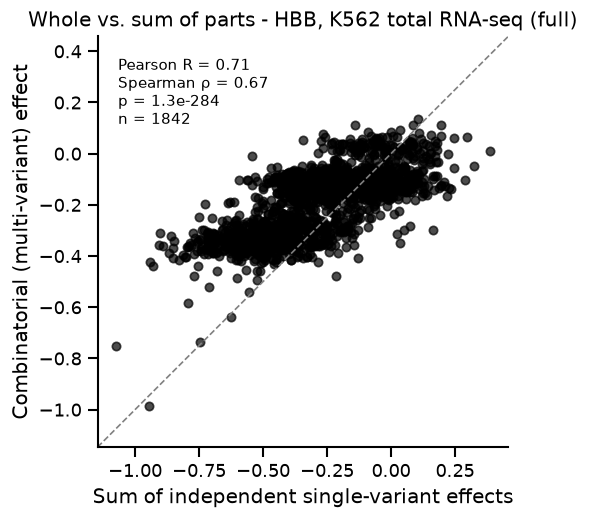

In [5]:
x = combined["sum_parts_score"].to_numpy()
y = combined["whole_score"].to_numpy()
r, p = stats.pearsonr(x, y)
rho, p_rho = stats.spearmanr(x, y)
n = len(combined)

fig, ax = plt.subplots(figsize=(4.5, 4.5))
ax.scatter(x, y, s=25, color="black", alpha=0.7)

lo, hi = min(x.min(), y.min()), max(x.max(), y.max())
pad = 0.05 * (hi - lo) if hi > lo else 1.0
ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], ls="--", color="gray", lw=1)
ax.set_xlim(lo - pad, hi + pad)
ax.set_ylim(lo - pad, hi + pad)
ax.set_aspect("equal", adjustable="box")

ax.set_xlabel("Sum of independent single-variant effects")
ax.set_ylabel("Combinatorial (multi-variant) effect")
ax.set_title(f"Whole vs. sum of parts - HBB, K562 total RNA-seq ({SCALE})")
ax.text(
    0.05, 0.95, f"Pearson R = {r:.2f}\nSpearman ρ = {rho:.2f}\np = {p:.1e}\nn = {n}",
    transform=ax.transAxes, ha="left", va="top", fontsize=9,
)
fig.tight_layout()

## Panel B — Compression vs. summed effect magnitude

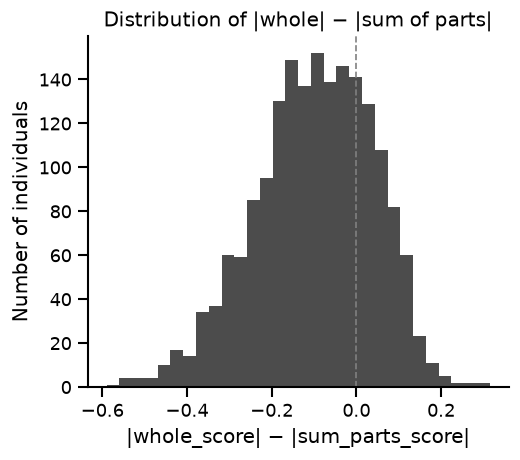

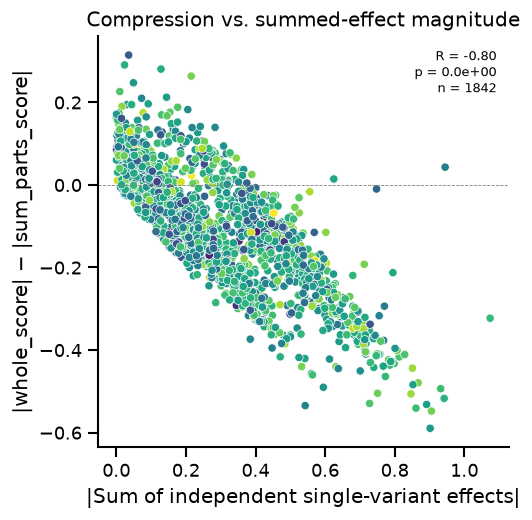

In [6]:
combined["abs_mag_diff"] = combined["whole_score"].abs() - combined["sum_parts_score"].abs()

fig, ax = plt.subplots(figsize=(4.5, 4))
ax.hist(combined["abs_mag_diff"], bins=30, color="black", alpha=0.7)
ax.axvline(0, color="gray", lw=1, ls="--")
ax.set_xlabel("|whole_score| − |sum_parts_score|")
ax.set_ylabel("Number of individuals")
ax.set_title("Distribution of |whole| − |sum of parts|")
fig.tight_layout()


fig, ax = plt.subplots(figsize=(4.5, 4.5))
sns.scatterplot(
    data=combined, x=combined["sum_parts_score"].abs(), y="abs_mag_diff",
    hue="n_variants_used", palette="viridis", s=25, ax=ax, legend=False,
)
ax.axhline(0, color="gray", lw=0.5, ls="--")
_annotate_corr(ax, combined["sum_parts_score"].abs().to_numpy(), combined["abs_mag_diff"].to_numpy())
ax.set_xlabel("|Sum of independent single-variant effects|")
ax.set_ylabel("|whole_score| − |sum_parts_score|")
ax.set_title("Compression vs. summed-effect magnitude")
fig.tight_layout()

## Panel C — Effective dimensionality

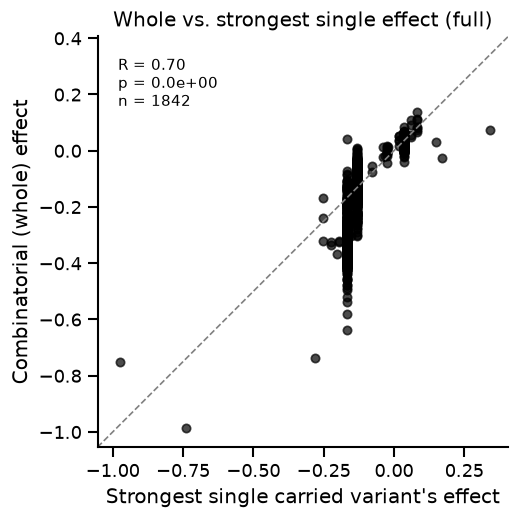

In [7]:
combined["strongest_single_score"] = combined["scores"].apply(
    lambda s: s[np.argmax(np.abs(s))] if len(s) else np.nan
)

x = combined["strongest_single_score"].to_numpy()
y = combined["whole_score"].to_numpy()
mask = np.isfinite(x) & np.isfinite(y)
r, p = stats.pearsonr(x[mask], y[mask])
n = mask.sum()

fig, ax = plt.subplots(figsize=(4.5, 4.5))
ax.scatter(x, y, s=25, color="black", alpha=0.7)
lo, hi = min(x[mask].min(), y[mask].min()), max(x[mask].max(), y[mask].max())
pad = 0.05 * (hi - lo) if hi > lo else 1.0
ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], ls="--", color="gray", lw=1)
ax.set_xlim(lo - pad, hi + pad)
ax.set_ylim(lo - pad, hi + pad)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("Strongest single carried variant's effect")
ax.set_ylabel("Combinatorial (whole) effect")
ax.set_title(f"Whole vs. strongest single effect ({SCALE})")
ax.text(
    0.05, 0.95, f"R = {r:.2f}\np = {p:.1e}\nn = {n}",
    transform=ax.transAxes, ha="left", va="top", fontsize=9,
)
fig.tight_layout()

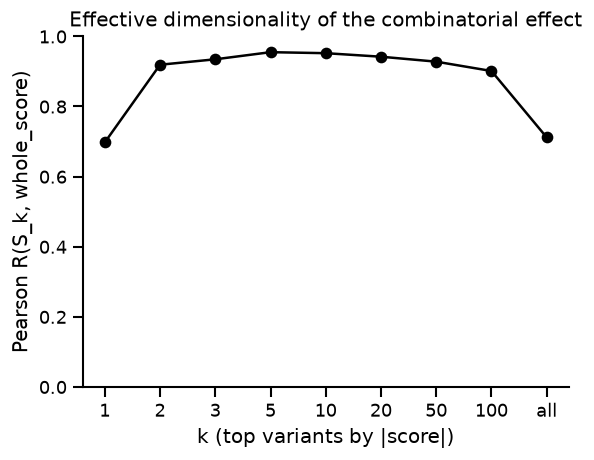

In [8]:
K_VALUES = [1, 2, 3, 5, 10, 20, 50, 100]


def _topk_sums(scores):
    if len(scores) == 0:
        return pd.Series({**{f"S_{k}": np.nan for k in K_VALUES}, "S_all": np.nan})
    order = np.argsort(-np.abs(scores))
    cumsum = np.cumsum(scores[order])
    out = {f"S_{k}": (cumsum[k - 1] if len(cumsum) >= k else cumsum[-1]) for k in K_VALUES}
    out["S_all"] = cumsum[-1]
    return pd.Series(out)

combined = pd.concat([combined, combined["scores"].apply(_topk_sums)], axis=1)

ks = K_VALUES + ["all"]
y = combined["whole_score"].to_numpy()
corrs = []
for k in ks:
    x = combined[f"S_{k}"].to_numpy()
    mask = np.isfinite(x) & np.isfinite(y)
    r, _ = stats.pearsonr(x[mask], y[mask])
    corrs.append(r)

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(range(len(ks)), corrs, marker="o", color="black")
ax.set_xticks(range(len(ks)))
ax.set_xticklabels([str(k) for k in ks])
ax.set_ylim(0, 1)
ax.set_xlabel("k (top variants by |score|)")
ax.set_ylabel("Pearson R(S_k, whole_score)")
ax.set_title("Effective dimensionality of the combinatorial effect")
fig.tight_layout()

## Panel D — Residual context-dependence

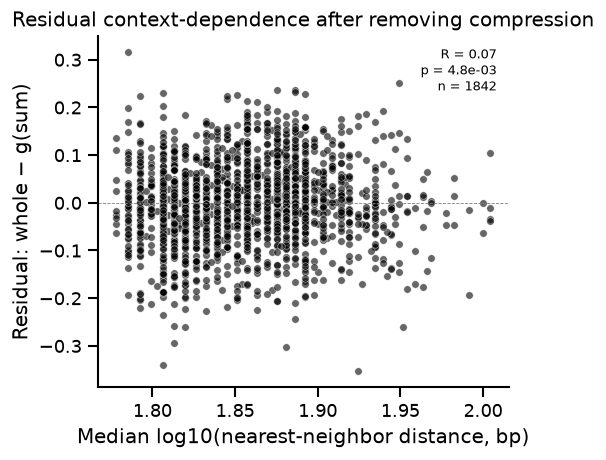

In [9]:
x = combined["sum_parts_score"].to_numpy()
y = combined["whole_score"].to_numpy()
mask = np.isfinite(x) & np.isfinite(y)

iso = IsotonicRegression(out_of_bounds="clip")
order = np.argsort(x[mask])
y_hat = np.empty(mask.sum())
y_hat[order] = iso.fit_transform(x[mask][order], y[mask][order])

residual = np.full(len(combined), np.nan)
residual[np.flatnonzero(mask)] = y[mask] - y_hat
combined["residual"] = residual

fig, ax = plt.subplots(figsize=(4.5, 4))
sns.scatterplot(
    data=combined, x="median_log10_nn_dist", y="residual",
    s=20, color="black", alpha=0.6, ax=ax,
)
ax.axhline(0, color="gray", lw=0.5, ls="--")
_annotate_corr(ax, combined["median_log10_nn_dist"].to_numpy(), combined["residual"].to_numpy())
ax.set_xlabel("Median log10(nearest-neighbor distance, bp)")
ax.set_ylabel("Residual: whole − g(sum)")
ax.set_title("Residual context-dependence after removing compression")
fig.tight_layout()

## Weak-tail accumulation control

,threshold,median_n_variants_kept,r_compression,p_compression
0,0.000,2844,-0.802387,0.0
1,0.005,774,-0.722032,0.0
2,0.010,92,-0.415064,0.0
3,0.020,4,-0.802807,0.0
4,0.050,1,-0.753994,0.0
5,0.100,1,-0.473322,0.0


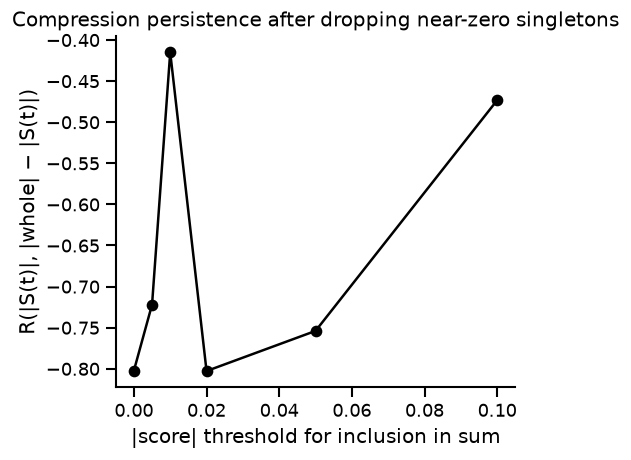

In [10]:
THRESHOLDS = [0.0, 0.005, 0.01, 0.02, 0.05, 0.1]


def _filtered_sum(scores, t):
    return scores[np.abs(scores) >= t].sum() if len(scores) else np.nan


def _n_kept(scores, t):
    return int(np.sum(np.abs(scores) >= t)) if len(scores) else 0

y = combined["whole_score"].to_numpy()
rows = []
for t in THRESHOLDS:
    s_t = combined["scores"].apply(lambda s: _filtered_sum(s, t)).to_numpy()
    n_kept = combined["scores"].apply(lambda s: _n_kept(s, t))
    mask = np.isfinite(s_t) & np.isfinite(y)
    mag_gap = np.abs(y[mask]) - np.abs(s_t[mask])
    r, p = stats.pearsonr(np.abs(s_t[mask]), mag_gap)
    rows.append({
        "threshold": t, "median_n_variants_kept": int(n_kept.median()),
        "r_compression": r, "p_compression": p,
    })

weak_tail = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(4.5, 4))
ax.plot(weak_tail["threshold"], weak_tail["r_compression"], marker="o", color="black")
ax.set_xlabel("|score| threshold for inclusion in sum")
ax.set_ylabel("R(|S(t)|, |whole| − |S(t)|)")
ax.set_title("Compression persistence after dropping near-zero singletons")
fig.tight_layout()

weak_tail

## Supplementary

### Individual clusters (GMM, k=3)

,count,mean,std,min,max
cluster,,,,,
0,712,-0.322386,0.068378,-0.987787,-0.192918
1,979,-0.115654,0.033501,-0.191808,-0.032367
2,151,0.026064,0.032232,-0.031514,0.136587


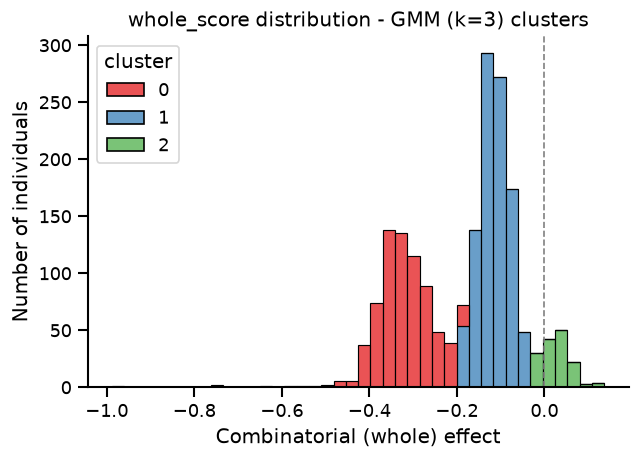

In [11]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=3, random_state=0)
raw_labels = gmm.fit_predict(combined[["whole_score"]].to_numpy())
cluster_order = (
    pd.Series(combined["whole_score"].to_numpy())
    .groupby(raw_labels).mean().sort_values().index
)
label_map = {old: new for new, old in enumerate(cluster_order)}
combined["cluster"] = pd.Categorical([label_map[l] for l in raw_labels])

fig, ax = plt.subplots(figsize=(5.5, 4))
sns.histplot(
    data=combined, x="whole_score", hue="cluster", bins=40,
    palette="Set1", multiple="stack", ax=ax,
)
ax.axvline(0, color="gray", lw=1, ls="--")
ax.set_xlabel("Combinatorial (whole) effect")
ax.set_ylabel("Number of individuals")
ax.set_title("whole_score distribution - GMM (k=3) clusters")
fig.tight_layout()

combined.groupby("cluster", observed=True)["whole_score"].agg(["count", "mean", "std", "min", "max"])

### Allele frequency vs. distance to TSS, by cluster

/users/diasfrazer/manglada/miniforge3/envs/wigttsoip/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


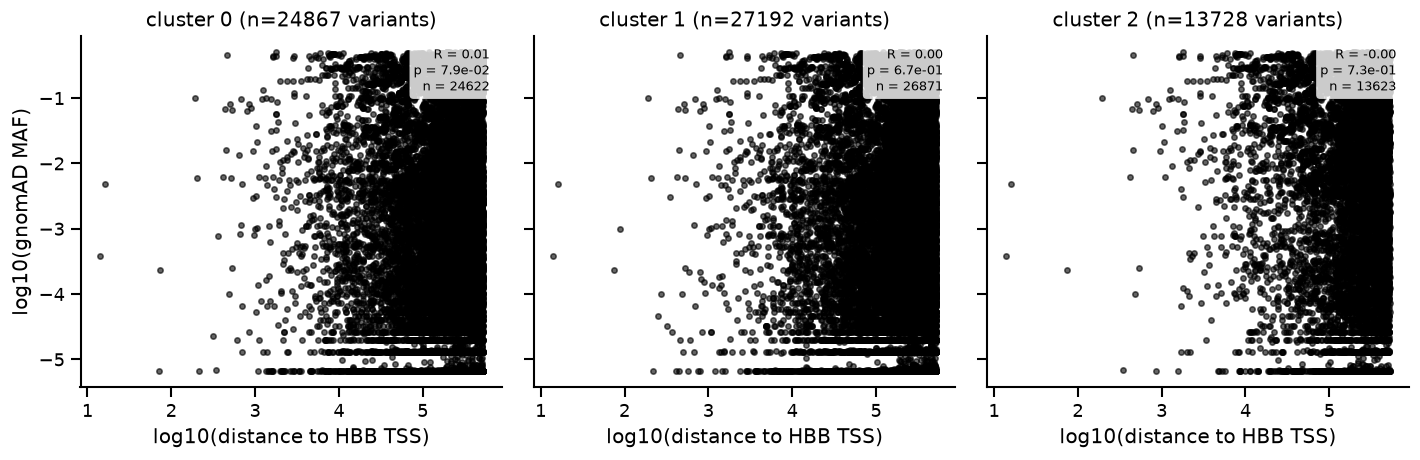

In [12]:
cluster_variants = {}
for c in sorted(combined["cluster"].cat.categories):
    variant_set = set()
    for variants in combined.loc[combined["cluster"] == c, "variants"]:
        variant_set.update(variants)
    cluster_variants[c] = variant_set

frames = []
for c, vset in cluster_variants.items():
    sub = singles[singles["variant"].isin(vset)].merge(maf, on="variant", how="inner").copy()
    sub["cluster"] = c
    frames.append(sub)
singles_by_cluster = pd.concat(frames, ignore_index=True)
singles_by_cluster["position"] = singles_by_cluster["variant"].str.split(":").str[1].astype(int)
singles_by_cluster["log10_maf"] = np.log10(singles_by_cluster["gnomad_maf"])
singles_by_cluster["log10_dist_tss"] = np.log10(
    np.where(singles_by_cluster["position"] == tss, 1, np.abs(singles_by_cluster["position"] - tss))
)

clusters = sorted(combined["cluster"].cat.categories)
fig, axes = plt.subplots(1, len(clusters), figsize=(4 * len(clusters), 4), sharex=True, sharey=True)
for ax, c in zip(axes, clusters):
    sub = singles_by_cluster[singles_by_cluster["cluster"] == c]
    ax.scatter(sub["log10_dist_tss"], sub["log10_maf"], s=10, color="black", alpha=0.6)
    _annotate_corr(ax, sub["log10_dist_tss"].to_numpy(), sub["log10_maf"].to_numpy())
    ax.set_xlabel("log10(distance to HBB TSS)")
    ax.set_title(f"cluster {c} (n={len(sub)} variants)")
axes[0].set_ylabel("log10(gnomAD MAF)")
fig.tight_layout()

### Extreme individuals

In [13]:
combined["diff"] = combined["whole_score"] - combined["sum_parts_score"]
extreme = pd.concat([
    combined.nlargest(10, "diff").assign(direction="synergy"),
    combined.nsmallest(10, "diff").assign(direction="antagonism"),
])[["sample", "direction", "whole_score", "sum_parts_score", "n_variants_used", "strongest_single_score"]]
display(extreme)

for _, row in extreme.iterrows():
    sample_row = combined.loc[combined["sample"] == row["sample"]].iloc[0]
    order = np.argsort(-np.abs(sample_row["scores"]))[:5]
    print(f"{row['sample']} ({row['direction']}, whole={row['whole_score']:.3f}):")
    for i in order:
        print(f"    {sample_row['variants'][i]}: {sample_row['scores'][i]:.4f}")

,sample,direction,whole_score,sum_parts_score,n_variants_used,strongest_single_score
98,HG00277,synergy,-0.312045,-0.901746,2794,-0.166646
33,HG00150,synergy,-0.357604,-0.905536,3352,-0.166646
765,HG01775,synergy,-0.320102,-0.860970,3129,-0.166646
861,HG01918,synergy,-0.007911,-0.542640,2573,-0.023794
6,HG00118,synergy,-0.359578,-0.891591,2813,-0.166646
1067,HG03489,synergy,-0.198494,-0.727840,3202,-0.166646
1413,HG04093,synergy,-0.424784,-0.942027,3009,-0.166646
645,HG01529,synergy,-0.340322,-0.846665,3493,-0.166646
628,HG01512,synergy,-0.245924,-0.750724,3336,-0.166646
519,HG01308,synergy,-0.438334,-0.932026,3130,-0.166646


HG00277 (synergy, whole=-0.312):
    chr11:5284832:A>C: -0.1666
    chr11:5227013:A>G: -0.1311
    chr11:5284837:A>C: -0.1020
    chr11:5221273:A>G: -0.0246
    chr11:4740466:A>G: -0.0187
HG00150 (synergy, whole=-0.358):
    chr11:5284832:A>C: -0.1666
    chr11:5227013:A>G: -0.1311
    chr11:5284837:A>C: -0.1020
    chr11:5284841:T>C: -0.0931
    chr11:5239228:T>C: 0.0345
HG01775 (synergy, whole=-0.320):
    chr11:5284832:A>C: -0.1666
    chr11:5227013:A>G: -0.1311
    chr11:5284837:A>C: -0.1020
    chr11:5284841:T>C: -0.0931
    chr11:5239228:T>C: 0.0345
HG01918 (synergy, whole=-0.008):
    chr11:5367672:G>C: -0.0238
    chr11:5498240:C>T: 0.0177
    chr11:4734635:A>G: -0.0166
    chr11:5480295:T>C: 0.0162
    chr11:5343750:A>C: -0.0154
HG00118 (synergy, whole=-0.360):
    chr11:5284832:A>C: -0.1666
    chr11:5227013:A>G: -0.1311
    chr11:5284837:A>C: -0.1020
    chr11:5284841:T>C: -0.0931
    chr11:5221273:A>G: -0.0246
HG03489 (synergy, whole=-0.198):
    chr11:5284832:A>C: -0.1666
